### Import libraries and datasets

In [1]:
import os
import glob
import numpy as np
import pandas as pd
import seaborn as sns
import pickle
import keras
import random
import matplotlib.pyplot as plt

from joblib import dump, load
from os import path
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE
from matplotlib.pyplot import *
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler
from sklearn.metrics import precision_score, recall_score, accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from keras.models import Sequential
from keras import Model, Input, layers, optimizers
from keras.layers import *

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=DeprecationWarning)

Filtered, categorized data by labels for more customized training

In [4]:
# Attack data
Label_path = r'C:/Users/ADMIN/Desktop/code_folders/Capstone_Project/Capstone_Project_model/Label_CSV'
rows = 200000
# rows = 300000
# Label_path = r'../Label_CSV'
# Brute_Force = pd.read_csv(Label_path + '/Brute_Force.csv', encoding='cp1252', index_col=None, header=0, nrows=rows)
# print("Read Completed for ", Label_path + '/Brute_Force.csv')
DDoS = pd.read_csv(Label_path + '/DDoS.csv', encoding='cp1252', index_col=None, header=0, nrows=rows)
print("Read Completed for ", Label_path + '/DDoS.csv')
DoS = pd.read_csv(Label_path + '/DoS.csv', encoding='cp1252', index_col=None, header=0, nrows=rows)
print("Read Completed for ", Label_path + '/DoS.csv')
Spoofing = pd.read_csv(Label_path + '/Spoofing.csv', encoding='cp1252', index_col=None, header=0, nrows=rows)
print("Read Completed for ", Label_path + '/Spoofing.csv')
Recon = pd.read_csv(Label_path + '/Recon.csv', encoding='cp1252', index_col=None, header=0, nrows=rows)
print("Read Completed for ", Label_path + '/Recon.csv')
Web_based = pd.read_csv(Label_path + '/Web_based.csv', encoding='cp1252', index_col=None, header=0, nrows=rows)
print("Read Completed for ", Label_path + '/Web_based.csv')
Mirai = pd.read_csv(Label_path + '/Mirai.csv', encoding='cp1252', index_col=None, header=0, nrows=rows)
print("Read Completed for ", Label_path + '/Mirai.csv')
list_attack = [DDoS, DoS, Spoofing, Recon, Mirai, Web_based]
attack = pd.concat(list_attack, axis=0, ignore_index=True)
attack = attack.sample(frac=1, random_state=42).reset_index(drop=True)
label_series = pd.Series(attack['Label'])
print(label_series.value_counts())


# Normal data
path = r'C:/Users/ADMIN/Desktop/code_folders/Capstone_Project/Capstone_Project_model/normal_traffic_cap_live'
all_normal_files = glob.glob(path + "/*.csv")
list_normal = []
for file in all_normal_files:
    normal = pd.read_csv(file, encoding='cp1252', index_col=None, header=0)
    list_normal.append(normal)
    print("Read Completed for ", file)
normal = pd.concat(list_normal, axis=0, ignore_index=True)
normal = normal.sample(frac=1, random_state=42).reset_index(drop=True)
normal['Label'] = 0
normal.drop_duplicates(keep='first', inplace = True)
normal.replace([np.inf, -np.inf], np.nan, inplace=True) # Replace inf and -inf with NaN, then drop the resulting NaNs
normal.dropna(inplace=True)    # dropna() removes any rows that contain NaN (missing) values; reset_index() resets the row index after dropping, so it's clean and continuous.
normal.reset_index(drop=True, inplace=True)
# normal = pd.read_csv('../Label_CSV/BENIGN.csv')
# normal = pd.read_csv('c:/Users/ADMIN/Downloads/live_features.csv')

print("Normal: ",normal.shape)
print("Attack: ",attack.shape)

Read Completed for  C:/Users/ADMIN/Desktop/code_folders/Capstone_Project/Capstone_Project_model/Label_CSV/DDoS.csv
Read Completed for  C:/Users/ADMIN/Desktop/code_folders/Capstone_Project/Capstone_Project_model/Label_CSV/DoS.csv
Read Completed for  C:/Users/ADMIN/Desktop/code_folders/Capstone_Project/Capstone_Project_model/Label_CSV/Spoofing.csv
Read Completed for  C:/Users/ADMIN/Desktop/code_folders/Capstone_Project/Capstone_Project_model/Label_CSV/Recon.csv
Read Completed for  C:/Users/ADMIN/Desktop/code_folders/Capstone_Project/Capstone_Project_model/Label_CSV/Web_based.csv
Read Completed for  C:/Users/ADMIN/Desktop/code_folders/Capstone_Project/Capstone_Project_model/Label_CSV/Mirai.csv
Label
Recon        200000
Mirai        200000
DDoS         200000
DoS          200000
Spoofing     187208
Web_based     16053
Name: count, dtype: int64
Read Completed for  C:/Users/ADMIN/Desktop/code_folders/Capstone_Project/Capstone_Project_model/normal_traffic_cap_live\network_data.csv
Read Comple

### 1st satge model (binary classification)

Ensure column align

In [5]:
common_columns = attack.columns.intersection(normal.columns)
attack = attack[common_columns]
normal = normal[common_columns]

Visual Compare Feature Distributions

Header_Length
Normal:  1032152
Attack:  1003261


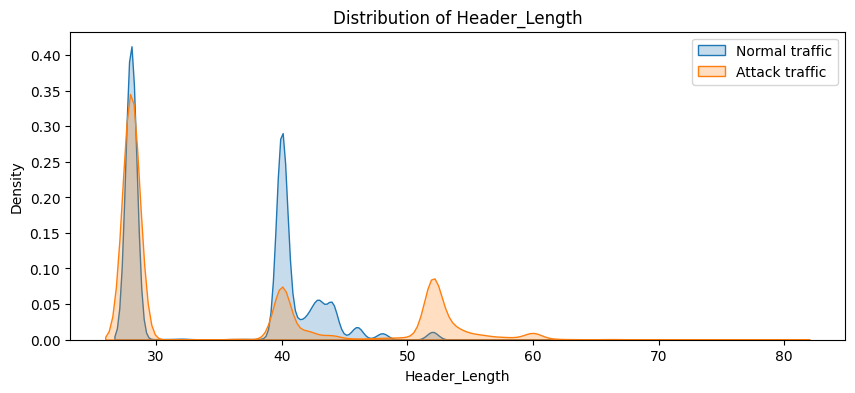

Protocol Type
Normal:  1032152
Attack:  1003261


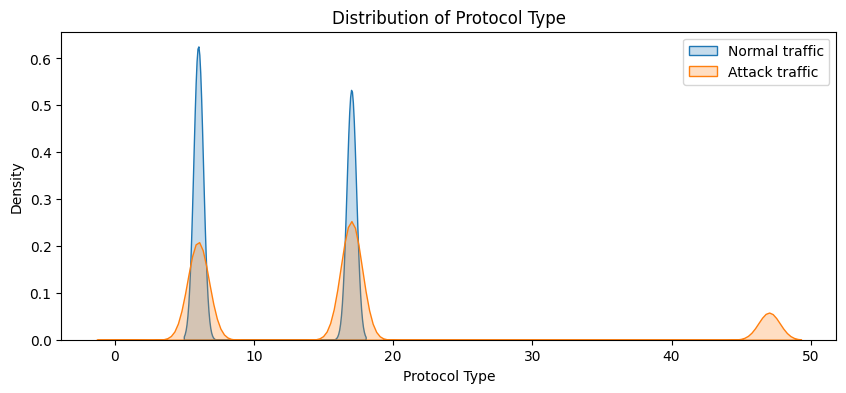

Time_To_Live
Normal:  1032152
Attack:  1003261


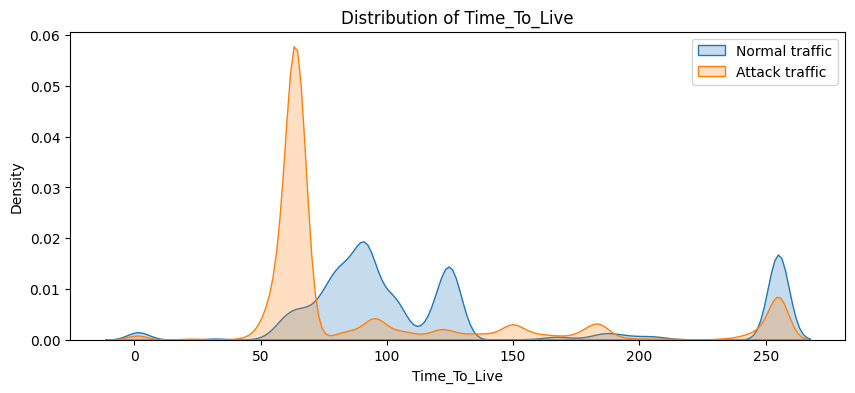

Rate
Normal:  1032152
Attack:  1003261


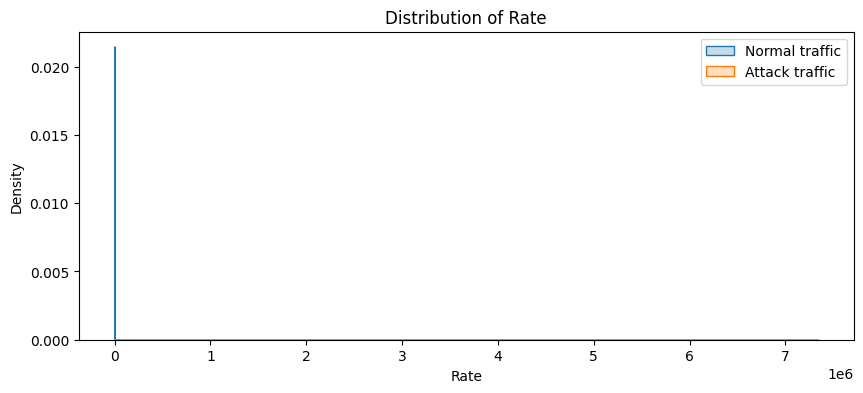

fin_flag_number
Normal:  1032152
Attack:  1003261


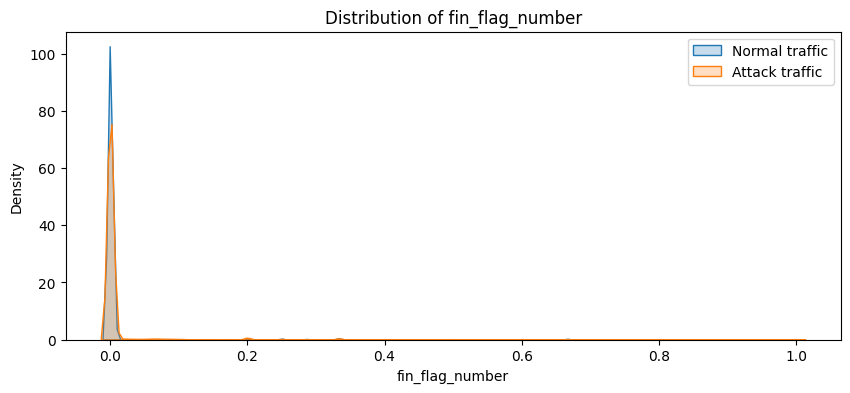

syn_flag_number
Normal:  1032152
Attack:  1003261


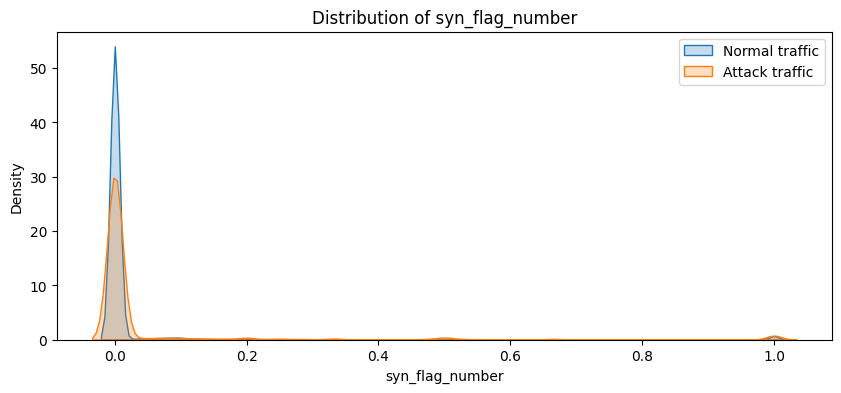

rst_flag_number
Normal:  1032152
Attack:  1003261


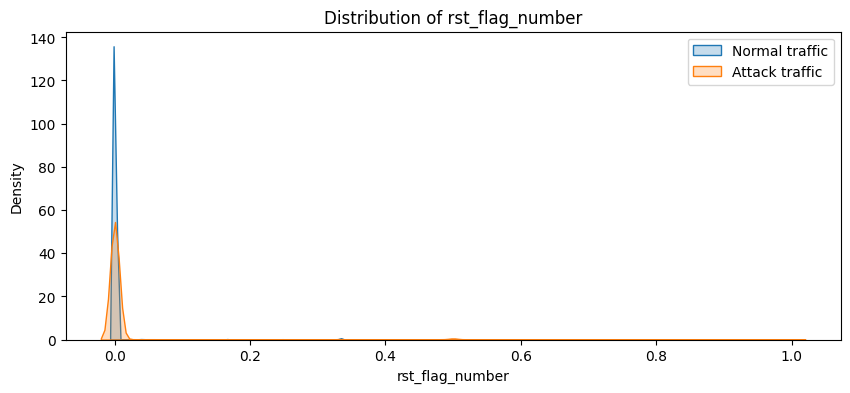

psh_flag_number
Normal:  1032152
Attack:  1003261


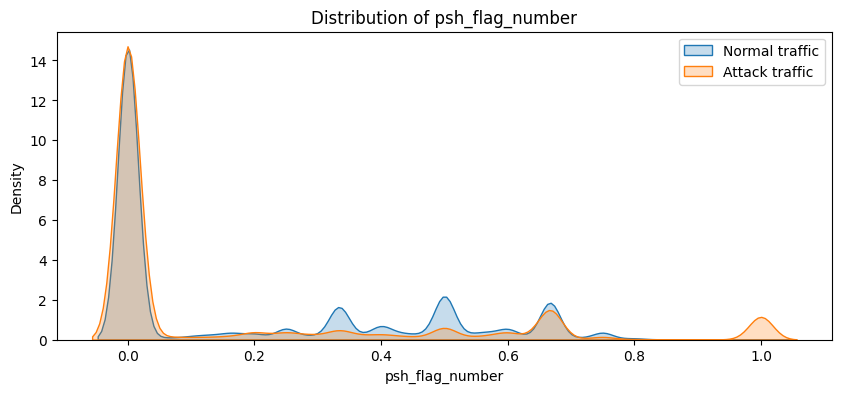

ack_flag_number
Normal:  1032152
Attack:  1003261


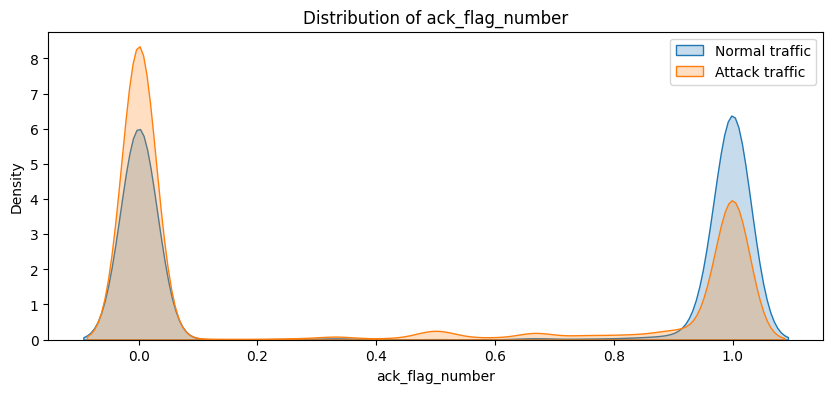

ece_flag_number
Normal:  1032152
Attack:  1003261


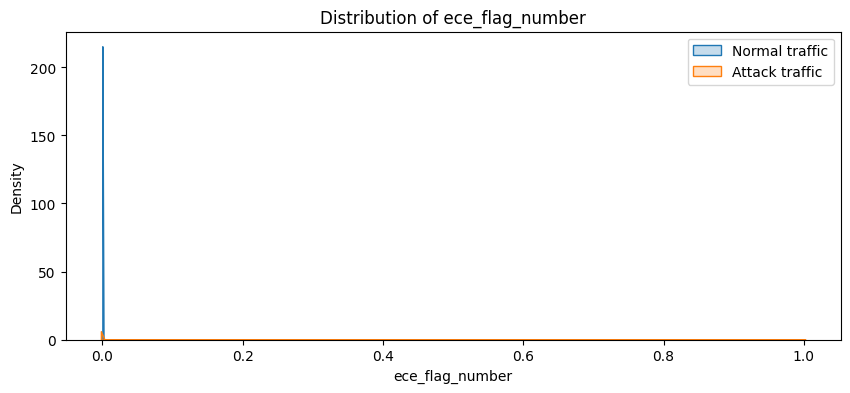

cwr_flag_number
Normal:  1032152
Attack:  1003261


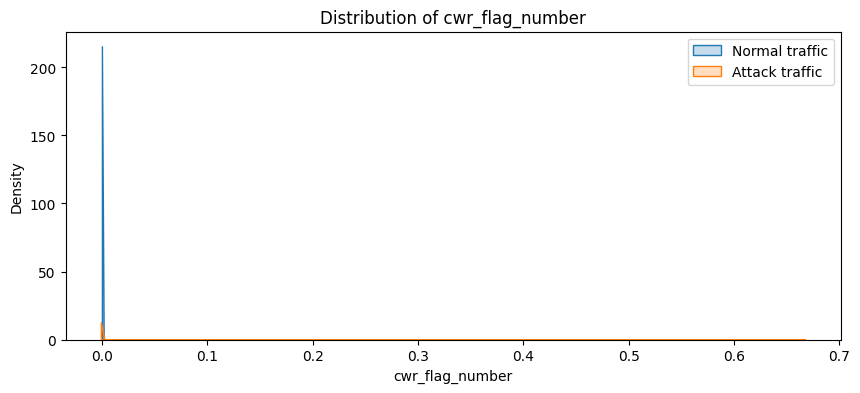

ack_count
Normal:  1032152
Attack:  1003261


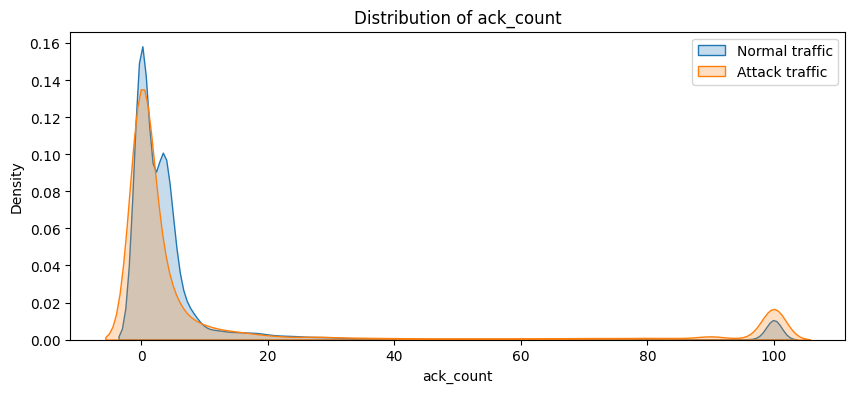

syn_count
Normal:  1032152
Attack:  1003261


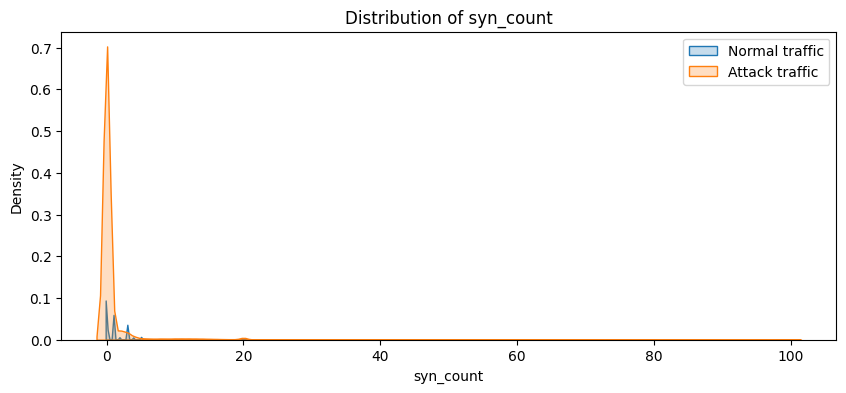

fin_count
Normal:  1032152
Attack:  1003261


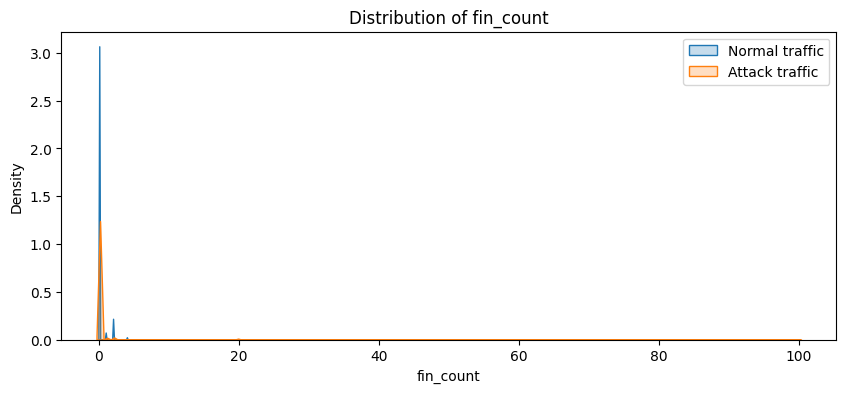

rst_count
Normal:  1032152
Attack:  1003261


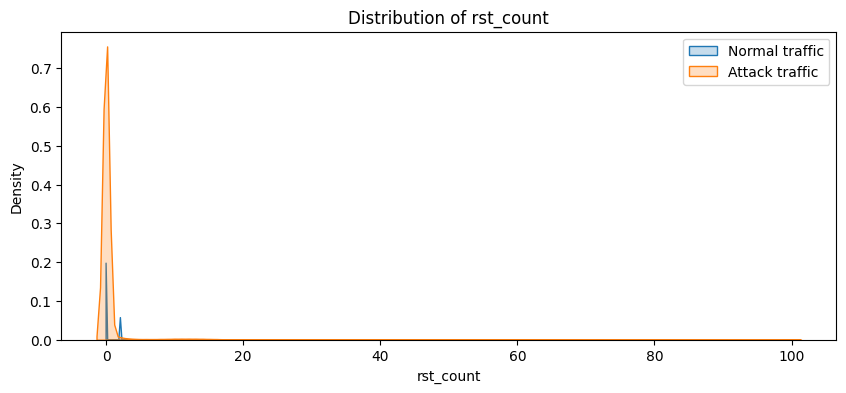

HTTP
Normal:  1032152
Attack:  1003261


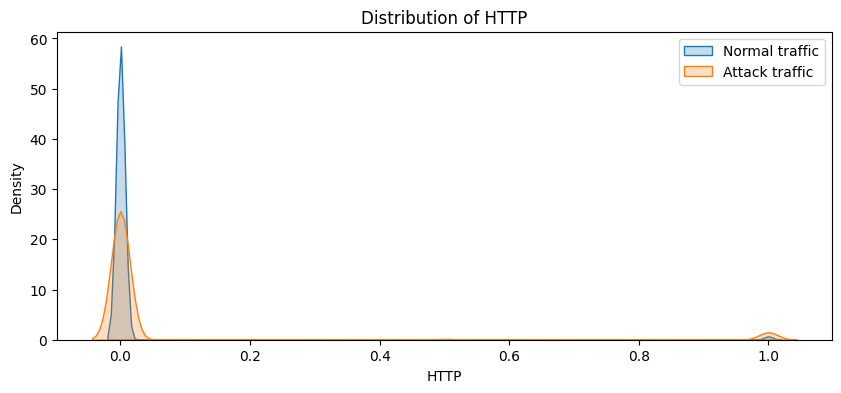

HTTPS
Normal:  1032152
Attack:  1003261


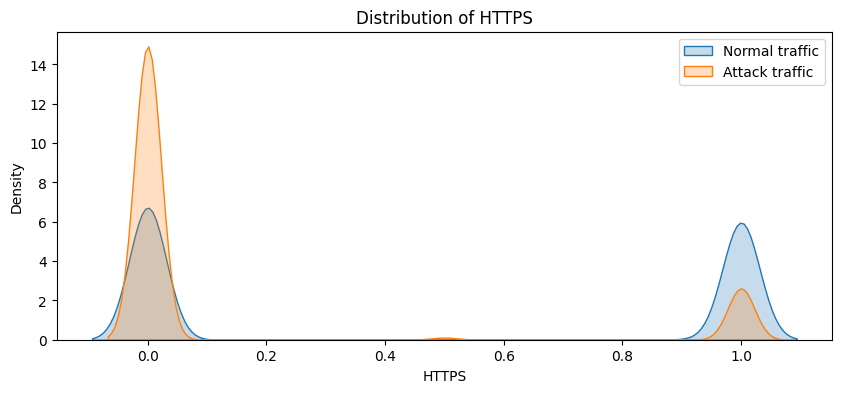

DNS
Normal:  1032152
Attack:  1003261


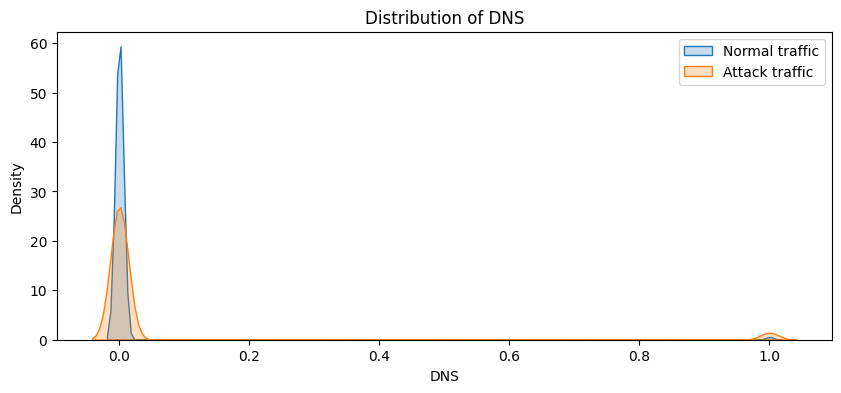

Telnet
Normal:  1032152
Attack:  1003261


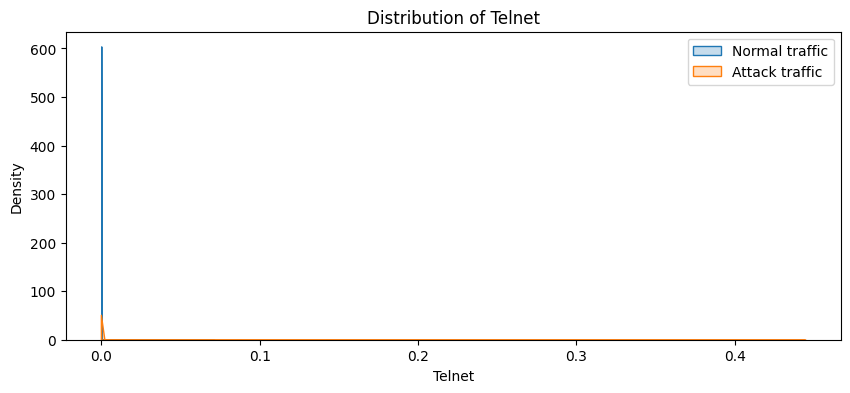

SMTP
Normal:  1032152
Attack:  1003261


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_8144\3656654131.py:6: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(normal[col], label='Normal traffic', fill=True)


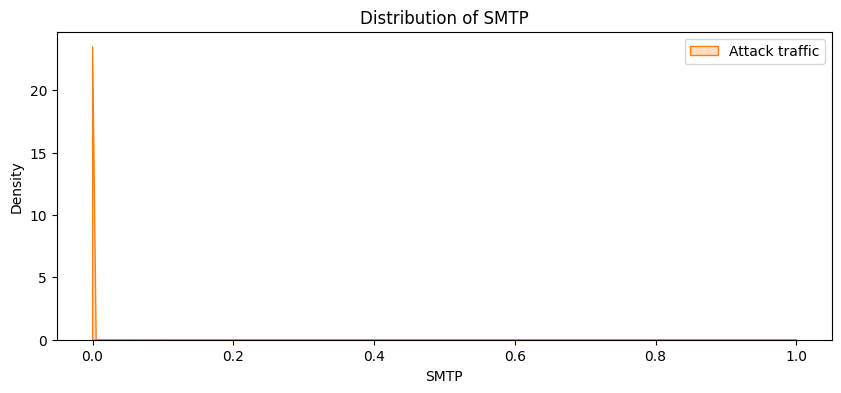

SSH
Normal:  1032152
Attack:  1003261


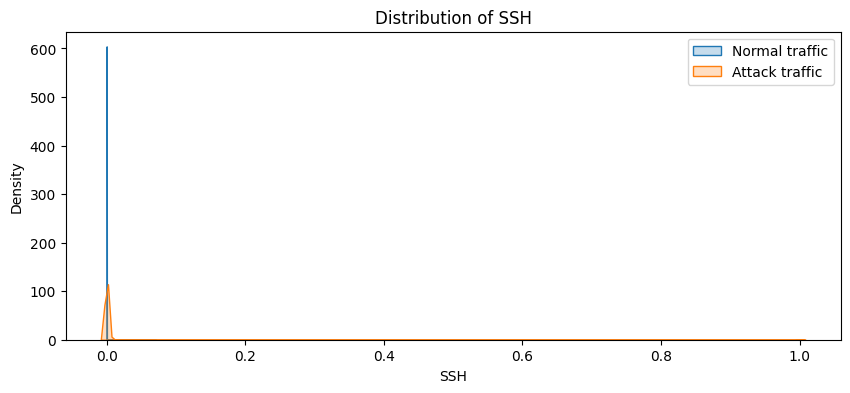

IRC
Normal:  1032152
Attack:  1003261


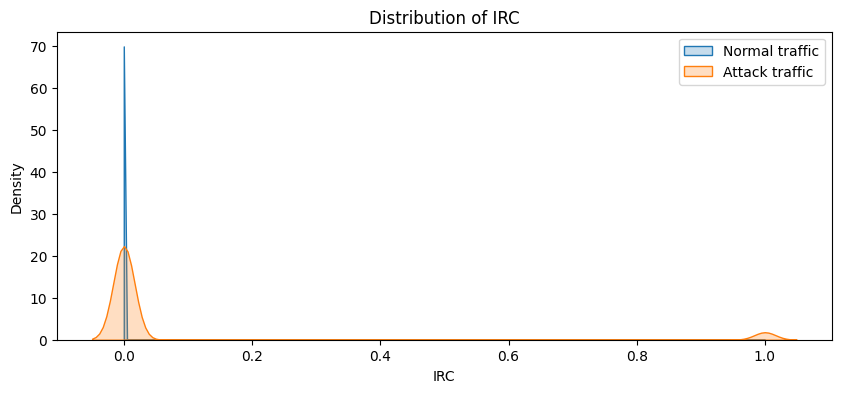

TCP
Normal:  1032152
Attack:  1003261


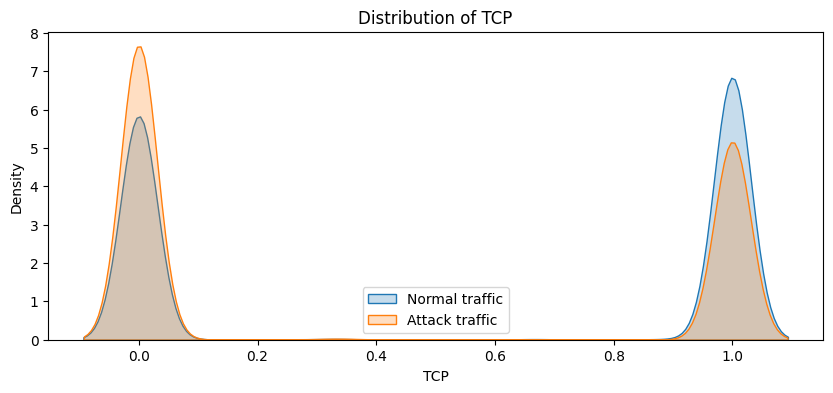

UDP
Normal:  1032152
Attack:  1003261


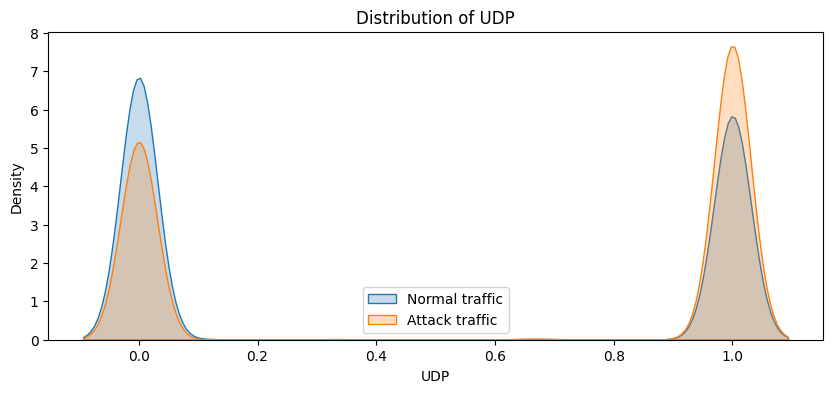

DHCP
Normal:  1032152
Attack:  1003261


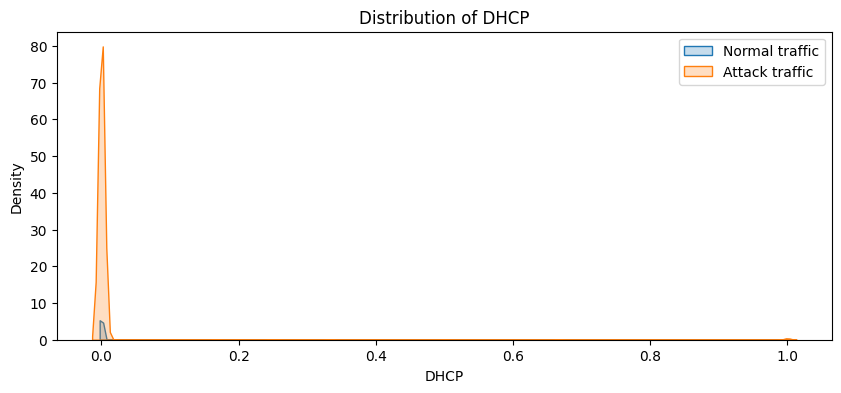

ARP
Normal:  1032152
Attack:  1003261


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_8144\3656654131.py:6: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(normal[col], label='Normal traffic', fill=True)
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_8144\3656654131.py:7: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(attack[col], label='Attack traffic', fill=True)
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_8144\3656654131.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


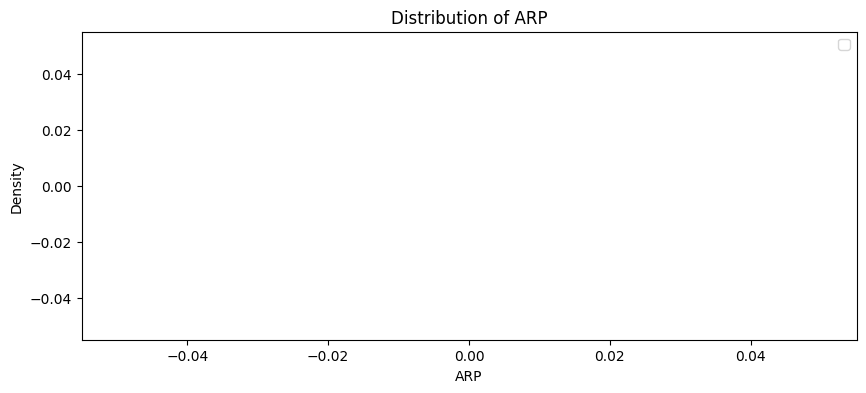

ICMP
Normal:  1032152
Attack:  1003261


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_8144\3656654131.py:6: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(normal[col], label='Normal traffic', fill=True)
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_8144\3656654131.py:7: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(attack[col], label='Attack traffic', fill=True)
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_8144\3656654131.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


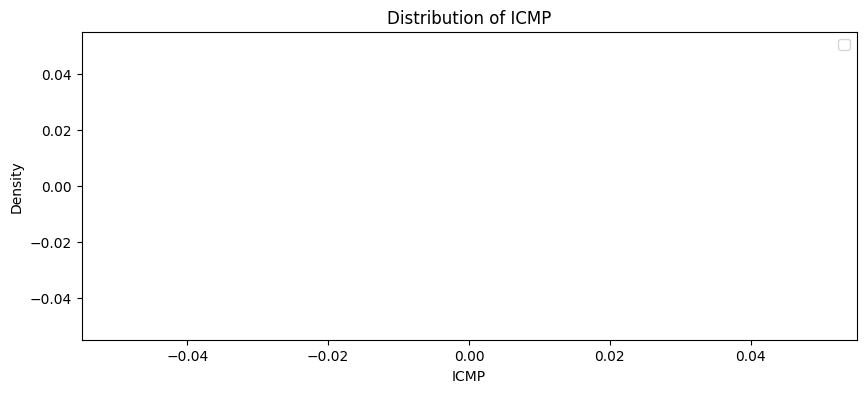

IGMP
Normal:  1032152
Attack:  1003261


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_8144\3656654131.py:6: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(normal[col], label='Normal traffic', fill=True)
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_8144\3656654131.py:7: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(attack[col], label='Attack traffic', fill=True)
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_8144\3656654131.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


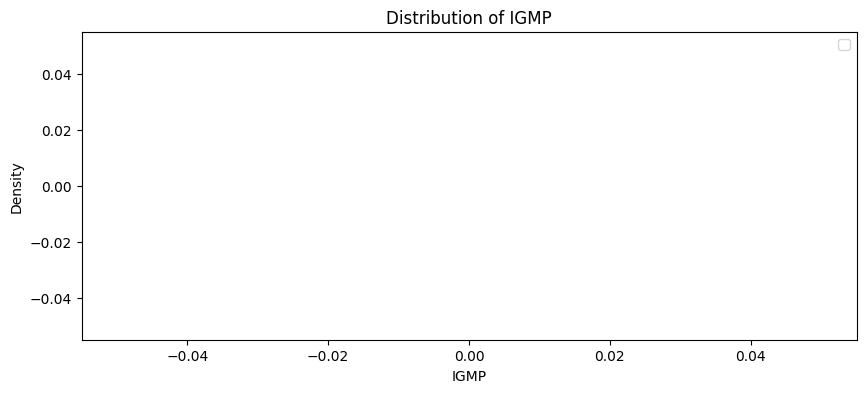

IPv
Normal:  1032152
Attack:  1003261


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_8144\3656654131.py:6: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(normal[col], label='Normal traffic', fill=True)
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_8144\3656654131.py:7: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(attack[col], label='Attack traffic', fill=True)
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_8144\3656654131.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


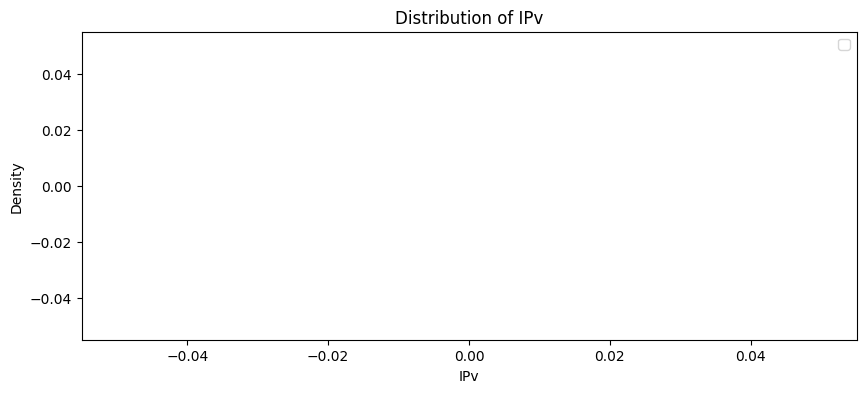

LLC
Normal:  1032152
Attack:  1003261


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_8144\3656654131.py:6: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(normal[col], label='Normal traffic', fill=True)
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_8144\3656654131.py:7: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(attack[col], label='Attack traffic', fill=True)
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_8144\3656654131.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


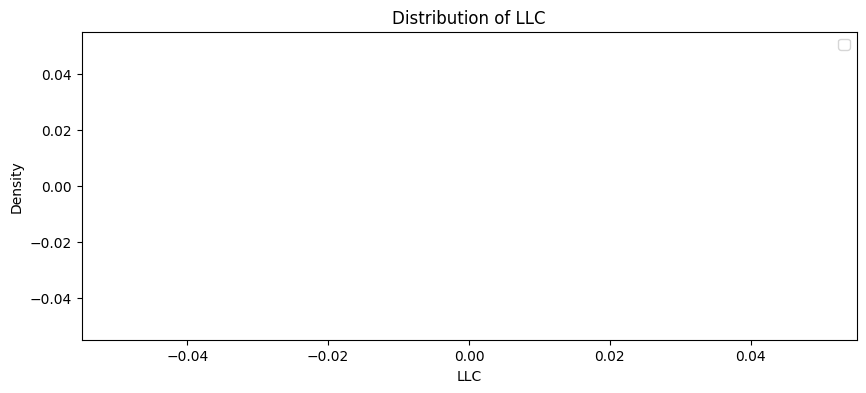

Tot sum
Normal:  1032152
Attack:  1003261


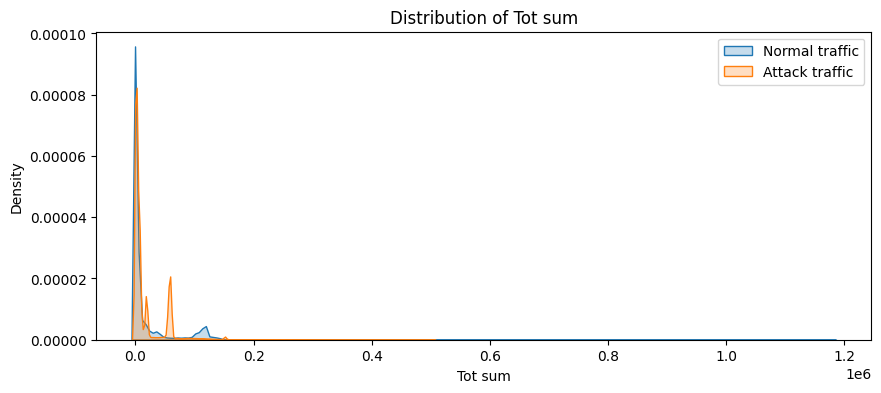

Min
Normal:  1032152
Attack:  1003261


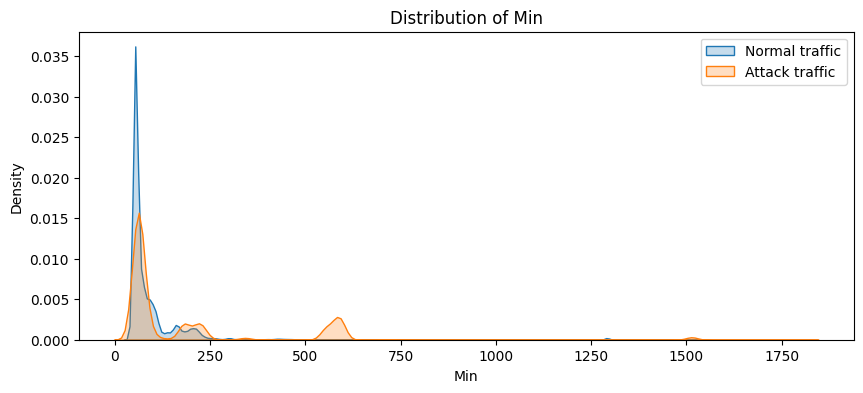

Max
Normal:  1032152
Attack:  1003261


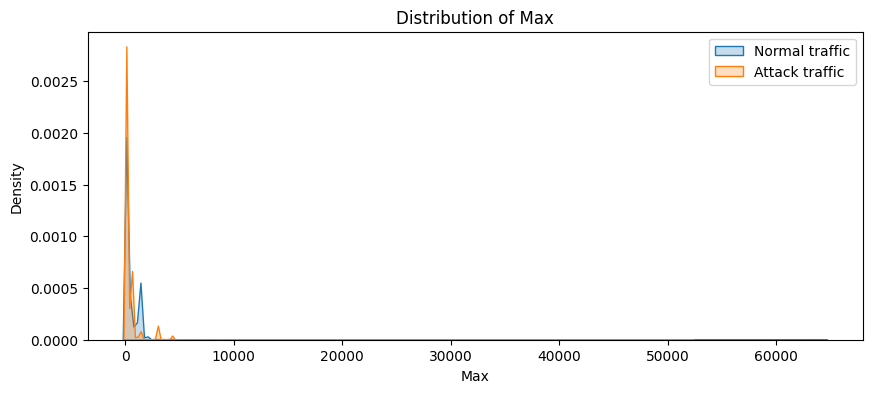

AVG
Normal:  1032152
Attack:  1003261


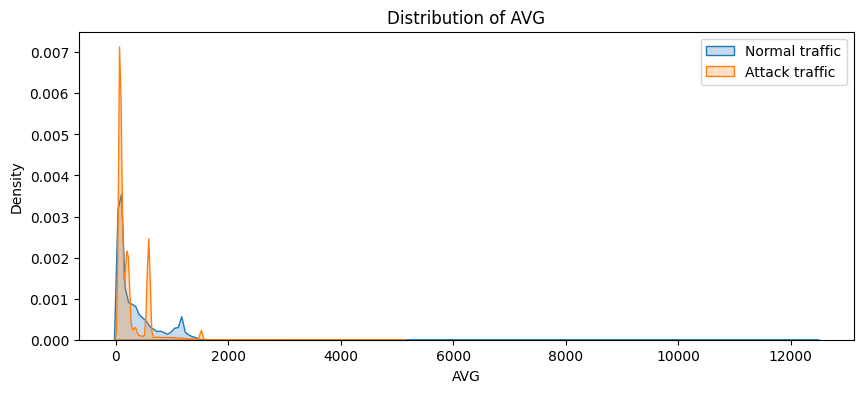

Std
Normal:  1032152
Attack:  1003261


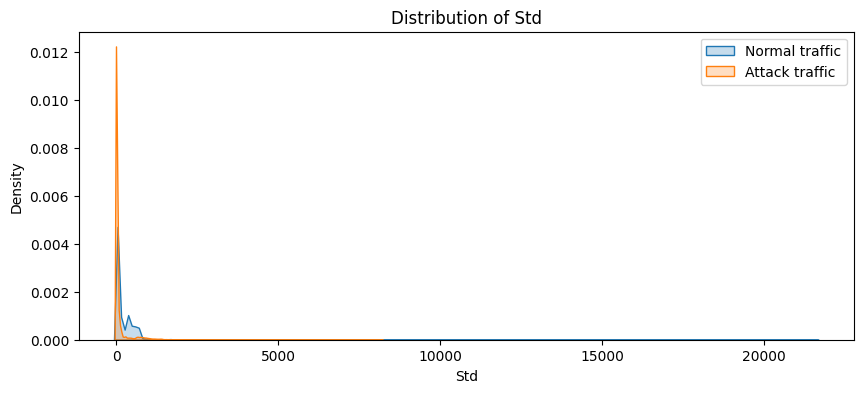

Tot size
Normal:  1032152
Attack:  1003261


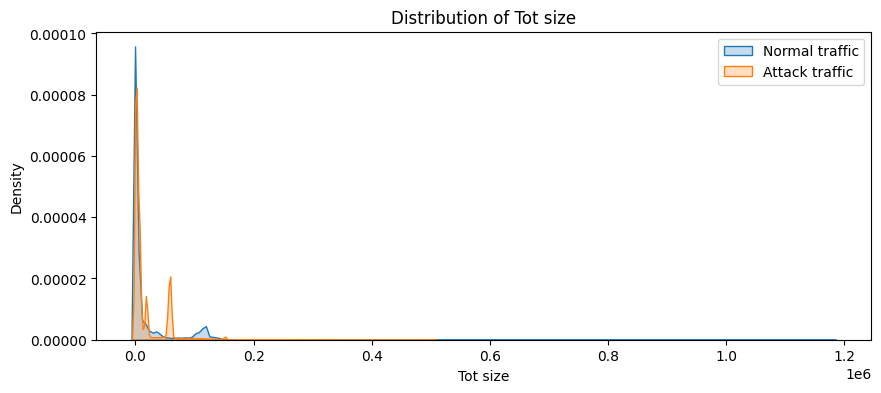

IAT
Normal:  1032152
Attack:  1003261


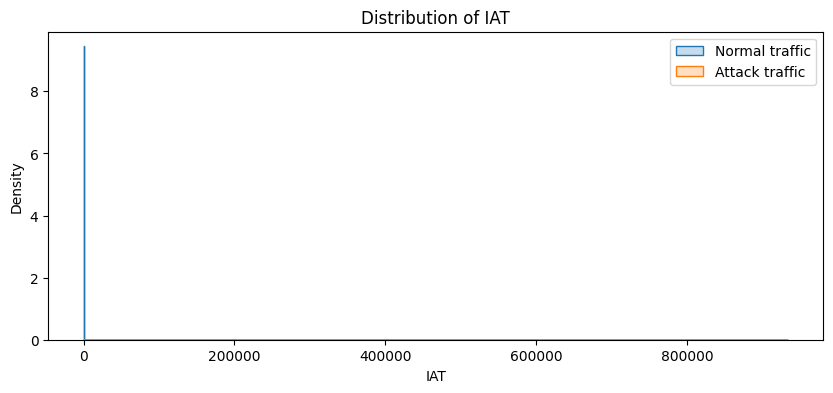

Number
Normal:  1032152
Attack:  1003261


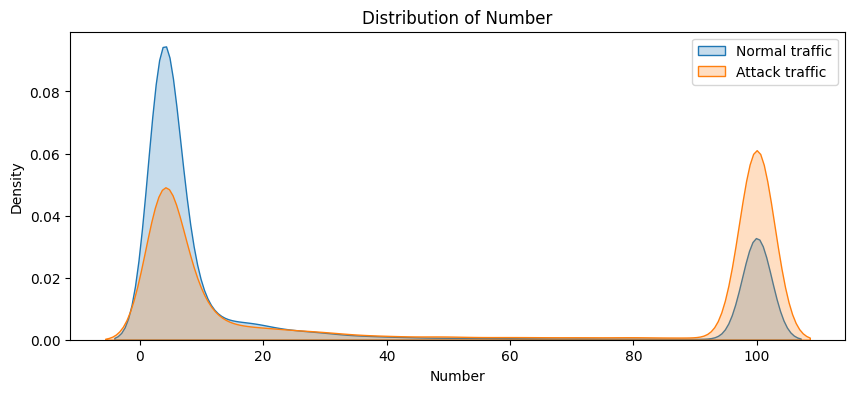

Variance
Normal:  1032152
Attack:  1003261


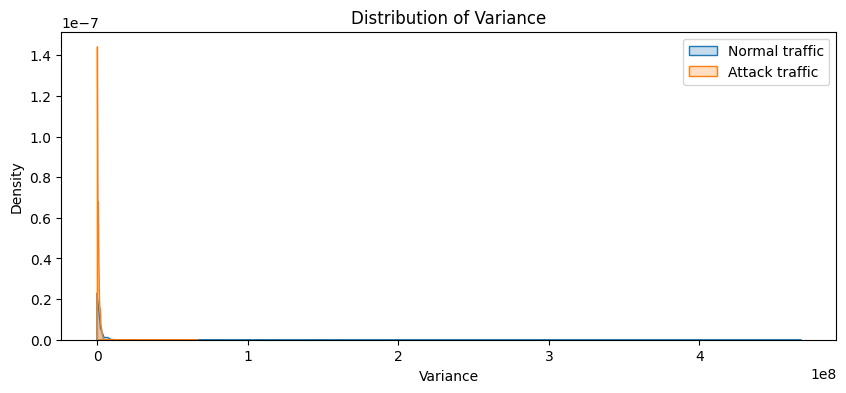

In [6]:
for col in common_columns.drop(['Label']):
    print(col)
    print("Normal: ", len(normal[col]))
    print("Attack: ", len(attack[col]))
    plt.figure(figsize=(10,4))
    sns.kdeplot(normal[col], label='Normal traffic', fill=True)
    sns.kdeplot(attack[col], label='Attack traffic', fill=True)
    plt.title(f'Distribution of {col}')
    plt.legend()
    plt.show()

In [7]:
dropped_columns =['fin_flag_number', 'rst_flag_number', 'ece_flag_number', 'cwr_flag_number', 'fin_count', 'rst_count', 'HTTP', 'Telnet', 'SMTP', 'SSH', 'DHCP', 'ARP', 'ICMP', 'IGMP', 'LLC', 'IPv']
# dropped_columns =[]
# 'Number'
# 'Time_To_Live', 'Min'
# Rate
# ack_flag_number 
# TCP
# ack_count
# UDP
# Number
# DNS
# IRC
# Protocol Type
# psh_flag_number
# syn_count
# syn_flag_number


Grouping main categories into one category for binary classification

In [8]:
def limit(data):
    limits = round((data.shape[0]*90)/100)
    return limits

attack_train = pd.concat([DDoS[:limit(DDoS)], DoS[:limit(DoS)], Mirai[:limit(Mirai)], Web_based[:limit(Web_based)], 
                          Spoofing[:limit(Spoofing)], Recon[:limit(Recon)]], axis=0, ignore_index=True)
attack_train = attack_train.drop(columns=dropped_columns)
print("Training attack data: ",attack_train.shape)


attack_test = pd.concat([DDoS[limit(DDoS):DDoS.shape[0]], DoS[limit(DoS):DoS.shape[0]], Mirai[limit(Mirai):Mirai.shape[0]], 
                         Web_based[limit(Web_based):Web_based.shape[0]], Spoofing[limit(Spoofing):Spoofing.shape[0]], 
                         Recon[limit(Recon):Recon.shape[0]]], axis=0, ignore_index=True)
attack_test = attack_test.drop(columns=dropped_columns)
print("Testing attack data: ",attack_test.shape)

Training attack data:  (902935, 24)
Testing attack data:  (100326, 24)


In [9]:
# Grouping
Attack = ['DDoS', 'Web_based', 'DoS', 'Brute_Force', 'Recon', 'Spoofing', 'Mirai']

def classify_attacks(data):
    data['Label'] = data['Label'].replace(Attack, 1)
    # Ensure labels are integers
    data['Label'] = data['Label'].astype(int)
classify_attacks(attack_train)
classify_attacks(attack_test)

In [10]:
normal = normal.drop(columns=dropped_columns)
print("Normal data: ",normal.shape)
limits = round(normal.shape[0]*90/100)
normal_train = normal[0:limits] 
print("Training normal data: ",normal_train.shape)
normal_test = normal[limits:normal.shape[0]]
print("Testing normal data: ",normal_test.shape)

Normal data:  (1032152, 24)
Training normal data:  (928937, 24)
Testing normal data:  (103215, 24)


In [11]:
df = pd.concat([attack_train, normal_train], axis=0, ignore_index=True)
# df = normal_train.drop(columns=['Label'])
df = df.sample(frac=1, random_state=42).reset_index(drop=True)
df.describe()
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1831872 entries, 0 to 1831871
Data columns (total 24 columns):
 #   Column           Dtype  
---  ------           -----  
 0   Header_Length    float64
 1   Protocol Type    int64  
 2   Time_To_Live     float64
 3   Rate             float64
 4   syn_flag_number  float64
 5   psh_flag_number  float64
 6   ack_flag_number  float64
 7   ack_count        int64  
 8   syn_count        int64  
 9   HTTPS            float64
 10  DNS              float64
 11  IRC              float64
 12  TCP              float64
 13  UDP              float64
 14  Tot sum          int64  
 15  Min              int64  
 16  Max              int64  
 17  AVG              float64
 18  Std              float64
 19  Tot size         int64  
 20  IAT              float64
 21  Number           int64  
 22  Variance         float64
 23  Label            int64  
dtypes: float64(15), int64(9)
memory usage: 335.4 MB


In [ ]:
df['Label'].value_counts()

In [12]:
# Train set preprocessing
df.drop_duplicates(keep='first', inplace = True)
df.replace([np.inf, -np.inf], np.nan, inplace=True) # Replace inf and -inf with NaN, then drop the resulting NaNs
df.dropna(inplace=True)    # dropna() removes any rows that contain NaN (missing) values; reset_index() resets the row index after dropping, so it's clean and continuous.
df.reset_index(drop=True, inplace=True)

In [13]:
columns_name = df.drop(columns=['Label']).columns

In [14]:
# Create train data
X_train_val = df.drop(columns=['Label'])
Y_train_val = df['Label']

In [15]:
print(X_train_val.shape)
print(Y_train_val.shape)

(1829716, 23)
(1829716,)


In [16]:
label_series = pd.Series(Y_train_val) # data_np is numPy type so it need to revert back to DataFrame to use value_counts
print(label_series.value_counts())

Label
0    928937
1    900779
Name: count, dtype: int64


In [17]:
# Under sampling
undersample = RandomUnderSampler(sampling_strategy='all') # if the strategy ='all' - normal undersample; if it a dict then the key is the name of the label and the value is 
                                                            # the target undersample - in this case '2' is the name of the 'DDOS' after encoded


X_train_val, Y_train_val = undersample.fit_resample(X_train_val, Y_train_val)

In [ ]:
# Over sampling
sm = SMOTE()
X_train_val, Y_train_val = sm.fit_resample(X_train_val, Y_train_val)

print(Y_train_val.shape)
print(X_train_val.shape)

In [18]:
label_series = pd.Series(Y_train_val) # data_np is numPy type so it need to revert back to DataFrame to use value_counts
print(label_series.value_counts())

Label
0    900779
1    900779
Name: count, dtype: int64


In [46]:
# Split the data set into training and testing
X_train, X_val, Y_train, Y_val = train_test_split(
    X_train_val, Y_train_val, test_size=0.2, random_state=33, shuffle=True)

In [47]:
X_train

,Header_Length,Protocol Type,Time_To_Live,Rate,syn_flag_number,psh_flag_number,ack_flag_number,ack_count,syn_count,HTTPS,...,UDP,Tot sum,Min,Max,AVG,Std,Tot size,IAT,Number,Variance
132091,28.0,17,64.000000,10807.276475,0.00,0.000000,0.000,0,0,0.0,...,1.0,6000,60,60,60.000000,0.000000,6000,0.000093,100,0.000000
1145001,40.6,6,192.800000,24.394399,0.05,0.300000,0.975,39,2,1.0,...,0.0,25256,54,2074,631.400000,707.102713,25256,0.013479,40,499994.246154
1386511,40.0,6,78.666667,50.012170,0.00,0.666667,1.000,3,0,1.0,...,0.0,859,60,666,286.333333,330.820697,859,0.308815,3,109442.333333
1337151,40.0,6,75.333333,11.100359,0.00,0.666667,1.000,3,0,0.0,...,0.0,168,54,57,56.000000,1.732051,168,0.170561,3,3.000000
1424955,52.0,6,61.500000,16.748825,0.00,0.500000,1.000,100,0,1.0,...,0.0,11148,66,172,111.480000,45.788817,11148,0.021085,100,2096.615758
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
263382,28.0,17,1.000000,0.247577,0.00,0.000000,0.000,0,0,0.0,...,1.0,654,218,218,218.000000,0.000000,654,0.017758,3,0.000000
759646,53.6,6,56.960000,12.835587,0.20,0.200000,0.900,90,20,0.5,...,0.0,10905,66,441,109.050000,101.822025,10905,0.022774,100,10367.724747
510895,60.0,6,64.000000,0.223324,1.00,0.000000,0.000,0,11,0.0,...,0.0,814,74,74,74.000000,0.000000,814,0.037920,11,0.000000
1761787,28.0,17,64.000000,34506.820239,0.00,0.000000,0.000,0,0,0.0,...,1.0,18200,182,182,182.000000,0.000000,18200,0.000029,100,0.000000


#### Neural Network

In [ ]:
_features = X_train.shape[1]

In [ ]:
nn_model = Sequential([
    Input(shape=(_features,)),

    # CNN layer structure
    # Convolution1D(256, 6, activation='relu'),
    # layers.BatchNormalization(),
    # MaxPooling1D(2),
    # Convolution1D(128, 6, activation='relu'),
    # layers.BatchNormalization(),
    # UpSampling1D(3),
    # Convolution1D(256, 6, activation='relu'),
    # Flatten(), # Maybe when we don't use lstm
    
    # LSTM layer structure
    # LSTM(512, return_sequences=False),
    # Dense(256, activation='relu'),
    
    # FNN layer structure
    Dense(256, activation='relu'), # Already have a Dense above
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.3),

    # Classification layer
    Dense(1, activation='sigmoid'),  # Softmax for multiclass, Sigmoid for binary, both use as output layer. Also, binary classification only have one output
])

In [ ]:
nn_model.summary()

In [ ]:
opt = optimizers.Adam(learning_rate=0.0001)
nn_model.compile(loss='binary_crossentropy',optimizer=opt, metrics=['accuracy'])
early_stop_callback = keras.callbacks.EarlyStopping(monitor='loss', patience=5)
reduce_lr = keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2,
                                  patience=3, min_lr=0.0001)

In [ ]:
start_fit = time.time()
history = nn_model.fit(X_train, Y_train,
                              batch_size=128,
                              epochs=10,
                              verbose=True,
                              validation_data=(X_val, Y_val))    

end_fit = time.time()
fit_time = end_fit - start_fit
print("fit time: {:.2f} seconds".format(fit_time))  

In [ ]:
test_set = pd.concat([attack_test, normal_test], axis=0, ignore_index=True)
# test_set = normal_train.drop(columns=['Label'])
test_set = test_set.sample(frac=1, random_state=42).reset_index(drop=True)

test_set.drop_duplicates(keep='first', inplace = True)
test_set.replace([np.inf, -np.inf], np.nan, inplace=True) # Replace inf and -inf with NaN, then drop the resulting NaNs
test_set.dropna(inplace=True)    # dropna() removes any rows that contain NaN (missing) values; reset_index() resets the row index after dropping, so it's clean and continuous.
test_set.reset_index(drop=True, inplace=True)

# Create test data
X_test = test_set.drop(columns=['Label'])
Y_test = test_set['Label']

y_pred_nn = nn_model.predict(X_test)
# y_pred_nn will be probabilities in [0,1]
y_pred_labels = (y_pred_nn > 0.5).astype(int).flatten()
print(classification_report(Y_test, y_pred_labels))

In [ ]:
# Test set preprocessing
normal_test.drop_duplicates(keep='first', inplace = True)
normal_test.replace([np.inf, -np.inf], np.nan, inplace=True) # Replace inf and -inf with NaN, then drop the resulting NaNs
normal_test.dropna(inplace=True)    # dropna() removes any rows that contain NaN (missing) values; reset_index() resets the row index after dropping, so it's clean and continuous.
normal_test.reset_index(drop=True, inplace=True)

X_sample = normal_test.drop(columns=['Label'])
Y_sample = normal_test['Label']

test_scaler = MinMaxScaler()
X_sample_scaled = test_scaler.fit_transform(X_sample)

score = 0
total = 1000

for i in range(total):
    # sample = X_test.iloc[[i]]  # Must be 2D
    sample = X_sample_scaled[-i].reshape(1, -1)  #If scaler is includeed, always reshape the data
    pred = nn_model.predict(sample)[0]
    pred_labels = (pred > 0.5).astype(int).flatten()
    actual = Y_sample.iloc[-i]

    if pred_labels == actual:
        score += 1
        
    print(f"Sample {-i}: Predicted = {pred_labels}, Actual = {actual}")

print("Percentage: ", (score/total)*100)

In [ ]:
attack_sample = DDoS.drop(columns=['fin_flag_number', 'syn_flag_number', 'rst_flag_number', 'psh_flag_number', 'ack_flag_number', 'ece_flag_number', 'cwr_flag_number', 'syn_count', 'fin_count', 'rst_count', 'Telnet', 'SMTP', 'SSH', 'IRC', 'ARP', 'IGMP', 'LLC', 'IAT', 'Number'])
# attack_sample = attack_test
# Test set preprocessing
attack_sample.drop_duplicates(keep='first', inplace = True)
attack_sample.replace([np.inf, -np.inf], np.nan, inplace=True) # Replace inf and -inf with NaN, then drop the resulting NaNs
attack_sample.dropna(inplace=True)    # dropna() removes any rows that contain NaN (missing) values; reset_index() resets the row index after dropping, so it's clean and continuous.
attack_sample.reset_index(drop=True, inplace=True)

X_sample = attack_sample.drop(columns=['Label'])
Y_sample = attack_sample['Label']

test_scaler = MinMaxScaler()
X_sample_scaled = test_scaler.fit_transform(X_sample)

score = 0
total = 500

for i in range(total):
    # sample = X_test.iloc[[i]]  # Must be 2D
    sample = X_sample_scaled[-i].reshape(1, -1)  #If scaler is includeed, always reshape the data
    pred = nn_model.predict(sample)[0]
    pred_labels = (pred > 0.5).astype(int).flatten()
    actual = Y_sample.iloc[-i]

    if pred_labels == actual:
        score += 1
        
    print(f"Sample {-i}: Predicted = {pred_labels}, Actual = {actual}")

print("Percentage: ", (score/total)*100)

#### Random Forest

In [48]:
frst_model = RandomForestClassifier(n_estimators=100,       # Default (reduce to 50-80 if too slow)
                                    max_depth=15,           # Limit tree depth to avoid overfitting + speed up
                                    min_samples_split=20,   # Reduce splits on small nodes
                                    min_samples_leaf=20,    # Prevent tiny leaves
                                    max_features='sqrt',    # Faster: only sqrt(features) per split
                                    class_weight="balanced",
                                    n_jobs=-1,              # Use all CPU cores
                                    #verbose=1,              # Show progress
                                    random_state=42)        # Reproducibility

frst_model.fit(X_train, Y_train)

RandomForestClassifier(class_weight='balanced', max_depth=15,
                       min_samples_leaf=20, min_samples_split=20, n_jobs=-1,
                       random_state=42)

In [49]:
y_pred_frst = frst_model.predict(X_val)
print(classification_report(Y_val, y_pred_frst))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99    180487
           1       1.00      0.99      0.99    179825

    accuracy                           0.99    360312
   macro avg       0.99      0.99      0.99    360312
weighted avg       0.99      0.99      0.99    360312



In [50]:
test_set = pd.concat([attack_test, normal_test], axis=0, ignore_index=True)
# test_set = normal_train.drop(columns=['Label'])
test_set = test_set.sample(frac=1, random_state=42).reset_index(drop=True)
print("Testing data: ", test_set.shape)

# Create test data
X_test = test_set.drop(columns=['Label'])
# X_test = scaler.transform(X_test) 
Y_test = test_set['Label']

Testing data:  (203541, 24)


In [43]:
# Under sampling
undersample = RandomUnderSampler(sampling_strategy='all') # if the strategy ='all' - normal undersample; if it a dict then the key is the name of the label and the value is 

X_test, Y_test = undersample.fit_resample(X_test, Y_test)

In [52]:
y_pred_frst = frst_model.predict(X_test)
print(classification_report(Y_test, y_pred_frst))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99    103215
           1       1.00      0.99      0.99    100326

    accuracy                           0.99    203541
   macro avg       0.99      0.99      0.99    203541
weighted avg       0.99      0.99      0.99    203541



Time_To_Live       0.201715
Min                0.100861
Variance           0.098725
Header_Length      0.091131
Std                0.087368
IAT                0.084067
Rate               0.053643
Max                0.048436
AVG                0.039255
HTTPS              0.027358
DNS                0.023745
Tot sum            0.021422
Tot size           0.020619
ack_count          0.017931
ack_flag_number    0.016251
UDP                0.015152
TCP                0.012432
Number             0.010387
IRC                0.010130
Protocol Type      0.006301
psh_flag_number    0.005965
syn_count          0.003749
syn_flag_number    0.003357
dtype: float64


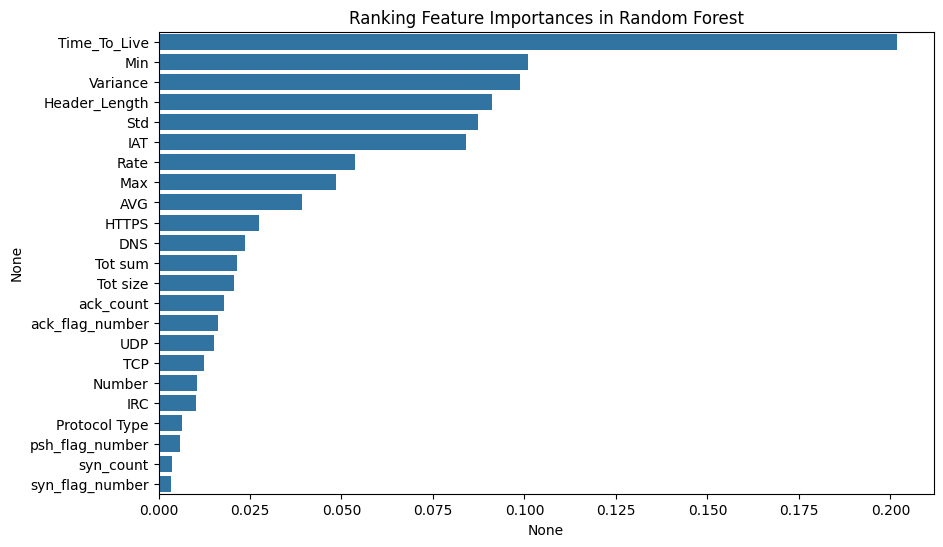

In [53]:
# Check feature importance
feat_importances = pd.Series(frst_model.feature_importances_, index=columns_name)
top_features = feat_importances.sort_values(ascending=False)
print(top_features)
plt.figure(figsize=(10,6))
sns.barplot(x=top_features, y=top_features.index)
plt.title("Ranking Feature Importances in Random Forest")
plt.show()

In [ ]:
# Save the model
with open('frst_model_1st_stage.pkl', 'wb') as f:
    pickle.dump(frst_model, f)

In [ ]:
# Load the model
with open('frst_model_1st_stage.pkl', 'rb') as f:
    frst_model = pickle.load(f)

Testing with individual normal network files

In [54]:
test = pd.read_csv('C:/Users/ADMIN/Desktop/code_folders/Capstone_Project/Capstone_Project_backend/network_data.csv', encoding='cp1252', index_col=None, header=0, nrows=rows).drop(columns=dropped_columns)
# test = pd.read_csv('C:/Users/ADMIN/Desktop/code_folders/Capstone_Project/network_logger/network_data.csv', encoding='cp1252', index_col=None, header=0, nrows=rows).drop(columns=dropped_columns)
# test = pd.read_csv('C:/Users/ADMIN/Desktop/code_folders/Capstone_Project/Capstone_Project_model/normal_traffic_cap_live/network_data_8.csv', encoding='cp1252', index_col=None, header=0, nrows=rows).drop(columns=dropped_columns)

score = 0

for i in range(100):
    sample = test.iloc[[i]]  # Must be 2D
    # print(sample)
    pred = frst_model.predict(sample)[0]
    if pred == 0:
        score += 1
    print(f"Sample {i}: Predicted = {pred}")
print("Percentage: ", score)

Sample 0: Predicted = 0
Sample 1: Predicted = 0
Sample 2: Predicted = 0
Sample 3: Predicted = 0
Sample 4: Predicted = 0
Sample 5: Predicted = 0
Sample 6: Predicted = 0
Sample 7: Predicted = 0
Sample 8: Predicted = 0
Sample 9: Predicted = 0
Sample 10: Predicted = 0
Sample 11: Predicted = 0
Sample 12: Predicted = 0
Sample 13: Predicted = 0
Sample 14: Predicted = 0
Sample 15: Predicted = 0
Sample 16: Predicted = 0
Sample 17: Predicted = 0
Sample 18: Predicted = 0
Sample 19: Predicted = 0
Sample 20: Predicted = 0
Sample 21: Predicted = 0
Sample 22: Predicted = 0
Sample 23: Predicted = 0
Sample 24: Predicted = 0
Sample 25: Predicted = 0
Sample 26: Predicted = 0
Sample 27: Predicted = 0
Sample 28: Predicted = 0
Sample 29: Predicted = 0
Sample 30: Predicted = 0
Sample 31: Predicted = 0
Sample 32: Predicted = 0
Sample 33: Predicted = 0
Sample 34: Predicted = 0
Sample 35: Predicted = 0
Sample 36: Predicted = 0
Sample 37: Predicted = 0
Sample 38: Predicted = 0
Sample 39: Predicted = 0
Sample 40:

In [55]:
test.drop_duplicates(keep='first', inplace = True)
test.replace([np.inf, -np.inf], np.nan, inplace=True) # Replace inf and -inf with NaN, then drop the resulting NaNs
test.dropna(inplace=True)    # dropna() removes any rows that contain NaN (missing) values; reset_index() resets the row index after dropping, so it's clean and continuous.
test.reset_index(drop=True, inplace=True)

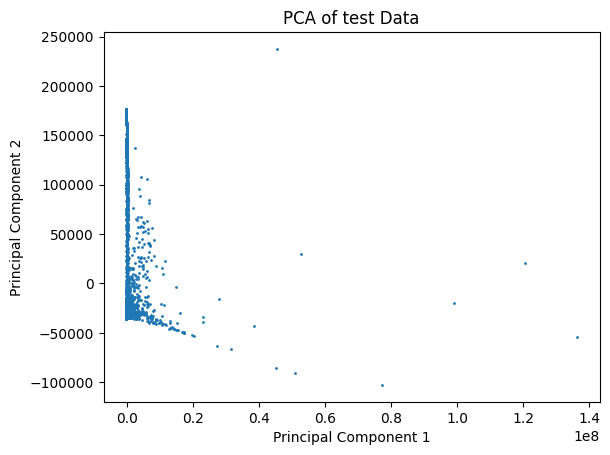

In [56]:
# Reduce to 2D
pcs = PCA(n_components=2)
X_pca = pcs.fit_transform(test)

# Plot
plt.scatter(X_pca[:, 0], X_pca[:, 1], s=1)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title("PCA of test Data")
plt.show()

In [57]:
X_sample = normal_test.drop(columns=['Label'])
Y_sample = normal_test['Label']

# X_sample_scaled = scaler.fit_transform(X_sample)

score = 0
total = 200

for i in range(total):
    sample = X_sample.iloc[[i]]  # Must be 2D
    # sample = X_sample[-i].reshape(1, -1)  #If scaler is includeed, always reshape the data
    pred = frst_model.predict(sample)[0]
    actual = Y_sample.iloc[-i]

    if pred == actual:
        score += 1
        
    print(f"Sample {i}: Predicted = {pred}, Actual = {actual}")

print("Percentage: ", (score/total)*100)

Sample 0: Predicted = 0, Actual = 0
Sample 1: Predicted = 0, Actual = 0
Sample 2: Predicted = 0, Actual = 0
Sample 3: Predicted = 0, Actual = 0
Sample 4: Predicted = 0, Actual = 0
Sample 5: Predicted = 0, Actual = 0
Sample 6: Predicted = 0, Actual = 0
Sample 7: Predicted = 0, Actual = 0
Sample 8: Predicted = 0, Actual = 0
Sample 9: Predicted = 0, Actual = 0
Sample 10: Predicted = 0, Actual = 0
Sample 11: Predicted = 0, Actual = 0
Sample 12: Predicted = 0, Actual = 0
Sample 13: Predicted = 0, Actual = 0
Sample 14: Predicted = 0, Actual = 0
Sample 15: Predicted = 0, Actual = 0
Sample 16: Predicted = 0, Actual = 0
Sample 17: Predicted = 0, Actual = 0
Sample 18: Predicted = 0, Actual = 0
Sample 19: Predicted = 0, Actual = 0
Sample 20: Predicted = 0, Actual = 0
Sample 21: Predicted = 0, Actual = 0
Sample 22: Predicted = 0, Actual = 0
Sample 23: Predicted = 0, Actual = 0
Sample 24: Predicted = 0, Actual = 0
Sample 25: Predicted = 0, Actual = 0
Sample 26: Predicted = 0, Actual = 0
Sample 27: 

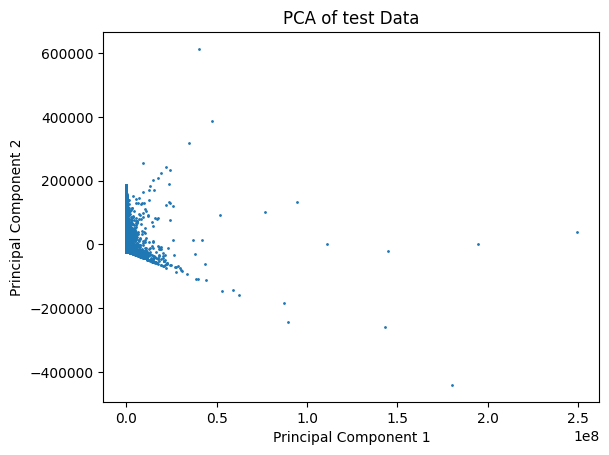

In [58]:
# Reduce to 2D
pcs = PCA(n_components=2)
X_pca = pcs.fit_transform(normal_test)

# Plot
plt.scatter(X_pca[:, 0], X_pca[:, 1], s=1)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title("PCA of test Data")
plt.show()

In [60]:
def data_range(data):
    limits = round(data.shape[0]*90/100)
    return data[limits:data.shape[0]]

def classify_attacks(data):
    data['Label'] = data['Label'].replace(['DDoS', 'Web_based', 'DoS', 'Recon', 'Spoofing', 'Mirai'], 1)
    # Ensure labels are integers
    data['Label'] = data['Label'].astype(int)

attack_sample = data_range(Web_based).drop(columns=dropped_columns)
# attack_sample = data_range(DDoS)
classify_attacks(attack_sample)
# attack_sample = attack_test

# attack_sample = pd.read_csv('C:/Users/ADMIN/Downloads/threat_logs.csv', encoding='cp1252', index_col=None, header=0).drop(columns=['fin_flag_number', 'syn_flag_number', 'rst_flag_number', 'psh_flag_number', 'ack_flag_number', 'ece_flag_number', 'cwr_flag_number', 'syn_count', 'fin_count', 'rst_count', 'Telnet', 'SMTP', 'SSH', 'IRC', 'ARP', 'IGMP', 'LLC', 'IAT', 'Number'])

# X_sample = attack_sample
X_sample = attack_sample.drop(columns=['Label'])
Y_sample = attack_sample['Label']

score = 0
total = 50

for i in range(total):
    sample = X_sample.iloc[[i]]  # Must be 2D
    # print(sample)
    # sample = X_sample_scaled[i].reshape(1, -1)  #If scaler is includeed, always reshape the data
    pred = frst_model.predict(sample)[0]
    actual = Y_sample.iloc[i]

    if pred == actual:
        score += 1
        
    print(f"Sample {i}: Predicted = {pred}, Actual = {actual}")
    # print(f"Sample {i}: Predicted = {pred}")

print("Percentage: ", (score/total)*100)

Sample 0: Predicted = 1, Actual = 1
Sample 1: Predicted = 1, Actual = 1
Sample 2: Predicted = 1, Actual = 1
Sample 3: Predicted = 1, Actual = 1
Sample 4: Predicted = 1, Actual = 1
Sample 5: Predicted = 1, Actual = 1
Sample 6: Predicted = 1, Actual = 1
Sample 7: Predicted = 1, Actual = 1
Sample 8: Predicted = 1, Actual = 1
Sample 9: Predicted = 1, Actual = 1
Sample 10: Predicted = 1, Actual = 1
Sample 11: Predicted = 1, Actual = 1
Sample 12: Predicted = 1, Actual = 1
Sample 13: Predicted = 1, Actual = 1
Sample 14: Predicted = 1, Actual = 1
Sample 15: Predicted = 1, Actual = 1
Sample 16: Predicted = 1, Actual = 1
Sample 17: Predicted = 1, Actual = 1
Sample 18: Predicted = 1, Actual = 1
Sample 19: Predicted = 1, Actual = 1
Sample 20: Predicted = 1, Actual = 1
Sample 21: Predicted = 1, Actual = 1
Sample 22: Predicted = 1, Actual = 1
Sample 23: Predicted = 1, Actual = 1
Sample 24: Predicted = 1, Actual = 1
Sample 25: Predicted = 1, Actual = 1
Sample 26: Predicted = 1, Actual = 1
Sample 27: 

### 2nd stage model (multiclass classification)

In [ ]:
dropped_columns = ['ICMP', 'IGMP', 'IPv', 'ARP', 'LLC', 'SMTP', 'Telnet', 'ece_flag_number', 'cwr_flag_number', 
                   'DHCP', 'IRC', 'SSH', 'fin_count', 'DNS', 'fin_flag_number', 'TCP', 'HTTP', 'rst_count', 'rst_flag_number']

In [62]:
def limit(data):
    limits = round(data.shape[0]*90/100)
    return limits

attack_train = pd.concat([DDoS[0:limit(DDoS)], DoS[0:limit(DoS)], Mirai[0:limit(Mirai)], Web_based[0:limit(Web_based)], 
                          Spoofing[0:limit(Spoofing)], Recon[0:limit(Recon)]], axis=0, ignore_index=True)
attack_train = attack_train.drop(columns = dropped_columns)
print("Training attack data: ",attack_train.shape)


attack_test = pd.concat([DDoS[limit(DDoS):DDoS.shape[0]], DoS[limit(DoS):DoS.shape[0]], Mirai[limit(Mirai):Mirai.shape[0]], 
                         Web_based[limit(Web_based):Web_based.shape[0]], Spoofing[limit(Spoofing):Spoofing.shape[0]], 
                         Recon[limit(Recon):Recon.shape[0]]], axis=0, ignore_index=True)
attack_test = attack_test.drop(columns = dropped_columns)
print("Testing attack data: ",attack_test.shape)

Training attack data:  (902935, 21)
Testing attack data:  (100326, 21)


In [63]:
columns_name = attack_train.drop(columns=['Label']).columns

In [64]:
# Train set preprocessing
attack_train.drop_duplicates(keep='first', inplace = True)
attack_train.replace([np.inf, -np.inf], np.nan, inplace=True) # Replace inf and -inf with NaN, then drop the resulting NaNs
attack_train.dropna(inplace=True)    # dropna() removes any rows that contain NaN (missing) values; reset_index() resets the row index after dropping, so it's clean and continuous.
attack_train.reset_index(drop=True, inplace=True)

In [65]:
# Create test data
X_train_val = attack_train.drop(columns=['Label'])
Y_train_val = attack_train['Label']

In [66]:
label_series = pd.Series(Y_train_val) # data_np is numPy type so it need to revert back to DataFrame to use value_counts
sample_limit = label_series.value_counts()[2]
print(label_series.value_counts())
print(sample_limit)

Label
Recon        180000
DDoS         179998
Mirai        179989
DoS          179726
Spoofing     168487
Web_based     14448
Name: count, dtype: int64
179989


In [ ]:
# Under sampling
undersample = RandomUnderSampler(sampling_strategy={'Recon':sample_limit, 'Spoofing':sample_limit}) # if the sampling_strategy='all' - normal undersample; if it a dict then the key is the name of the label and the value is 
                                                            # the target undersample - in this case '2' is the name of the 'DDOS' after encoded


X_train_val, Y_train_val = undersample.fit_resample(X_train_val, Y_train_val)

In [67]:
# Over sampling
sm = SMOTE()
X_train_val, Y_train_val = sm.fit_resample(X_train_val, Y_train_val)

print(Y_train_val.shape)
print(X_train_val.shape)

(1080000,)
(1080000, 20)


In [68]:
label_series = pd.Series(Y_train_val) # data_np is numPy type so it need to revert back to DataFrame to use value_counts
print(label_series.value_counts())

Label
DDoS         180000
DoS          180000
Mirai        180000
Web_based    180000
Spoofing     180000
Recon        180000
Name: count, dtype: int64


In [69]:
# Split the data set into training and testing
X_train, X_val, Y_train, Y_val = train_test_split(
    X_train_val, Y_train_val, test_size=0.2, random_state=33, shuffle=True)

In [70]:
frst_model = RandomForestClassifier(n_estimators=100,       # Default (reduce to 50-80 if too slow)
                                    max_depth=50,           # Limit tree depth to avoid overfitting + speed up
                                    min_samples_split=100,   # Reduce splits on small nodes
                                    min_samples_leaf=50,    # Prevent tiny leaves
                                    max_features='sqrt',    # Faster: only sqrt(features) per split
                                    n_jobs=-1,              # Use all CPU cores
                                    #verbose=1,              # Show progress
                                    random_state=42)        # Reproducibility

frst_model.fit(X_train, Y_train)

y_pred_frst = frst_model.predict(X_val)
print(classification_report(Y_val, y_pred_frst))

              precision    recall  f1-score   support

        DDoS       0.88      0.76      0.81     35798
         DoS       0.83      0.82      0.82     35865
       Mirai       0.92      0.87      0.89     36119
       Recon       0.70      0.74      0.72     36092
    Spoofing       0.70      0.71      0.71     35846
   Web_based       0.71      0.78      0.74     36280

    accuracy                           0.78    216000
   macro avg       0.79      0.78      0.78    216000
weighted avg       0.79      0.78      0.78    216000



In [71]:
'''
n_estimators=100,       
max_depth=25,           
min_samples_split=15,   
min_samples_leaf=15,    
max_features='sqrt',    
n_jobs=-1,              
#verbose=1,              
random_state=42
'''
X_test = attack_test.drop(columns=['Label'])
Y_test = attack_test['Label']
y_pred_frst_test = frst_model.predict(X_test)
print(classification_report(Y_test, y_pred_frst_test))

              precision    recall  f1-score   support

        DDoS       0.87      0.76      0.81     20000
         DoS       0.83      0.80      0.82     20000
       Mirai       0.92      0.87      0.89     20000
       Recon       0.81      0.74      0.78     20000
    Spoofing       0.71      0.72      0.71     18721
   Web_based       0.14      0.62      0.23      1605

    accuracy                           0.78    100326
   macro avg       0.71      0.75      0.71    100326
weighted avg       0.82      0.78      0.79    100326



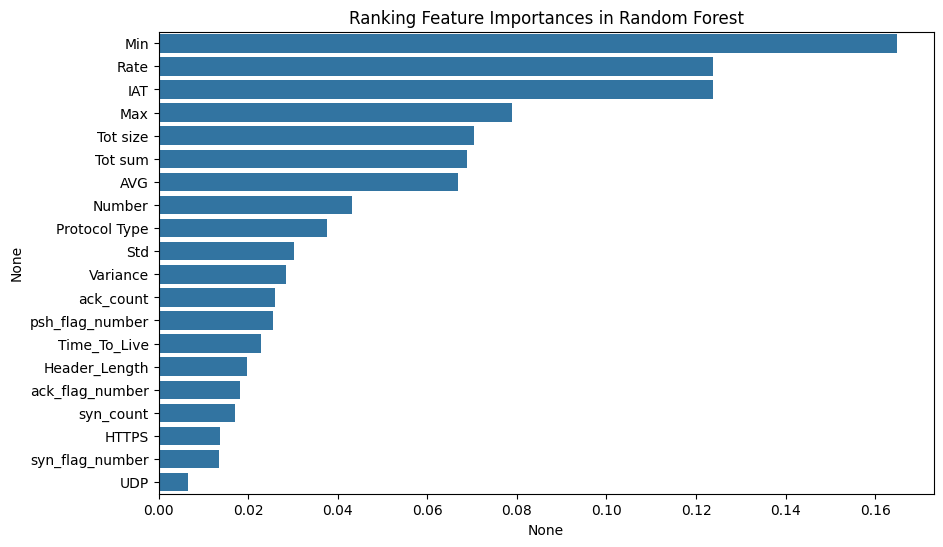

In [72]:
# Check feature importance
feat_importances = pd.Series(frst_model.feature_importances_, index=columns_name)
top_features = feat_importances.sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=top_features, y=top_features.index)
plt.title("Ranking Feature Importances in Random Forest")
plt.show()

In [ ]:
# Save the model
with open('frst_model_2nd_stage.pkl', 'wb') as f:
    pickle.dump(frst_model, f)

In [ ]:
# Load the model
with open('frst_model_2nd_stage.pkl', 'rb') as f:
    frst_model = pickle.load(f)

Testing with individual attack file

In [73]:
def data_range(data):
    limits = round(data.shape[0]*90/100)
    return data[limits:data.shape[0]]

attack_sample = data_range(Web_based).drop(columns=dropped_columns)
# attack_sample = data_range(DDoS)
# attack_sample = attack_test
# attack_sample = pd.read_csv('C:/Users/ADMIN/Downloads/DDoS-HTTP_Flood-.pcap.csv', encoding='cp1252', index_col=None, header=0)

# X_sample = attack_sample
X_sample = attack_sample.drop(columns=['Label'])
Y_sample = attack_sample['Label']

score = 0
total = 200

for i in range(total):
    sample = X_sample.iloc[[i]]  # Must be 2D
    # sample = X_sample_scaled[- i].reshape(1, -1)  #If scaler is includeed, always reshape the data
    pred = frst_model.predict(sample)[0]
    actual = Y_sample.iloc[- i]

    if pred == actual:
        score += 1

    print(f"Sample {i}: Predicted = {pred}, Actual = {actual}")
    # print(f"Sample {i}: Predicted = {pred}")

print("Percentage: ", (score/total)*100)

Sample 0: Predicted = Web_based, Actual = Web_based
Sample 1: Predicted = Spoofing, Actual = Web_based
Sample 2: Predicted = Web_based, Actual = Web_based
Sample 3: Predicted = Web_based, Actual = Web_based
Sample 4: Predicted = Recon, Actual = Web_based
Sample 5: Predicted = Web_based, Actual = Web_based
Sample 6: Predicted = Recon, Actual = Web_based
Sample 7: Predicted = Web_based, Actual = Web_based
Sample 8: Predicted = Web_based, Actual = Web_based
Sample 9: Predicted = Spoofing, Actual = Web_based
Sample 10: Predicted = Web_based, Actual = Web_based
Sample 11: Predicted = Web_based, Actual = Web_based
Sample 12: Predicted = Web_based, Actual = Web_based
Sample 13: Predicted = Recon, Actual = Web_based
Sample 14: Predicted = Web_based, Actual = Web_based
Sample 15: Predicted = Web_based, Actual = Web_based
Sample 16: Predicted = Web_based, Actual = Web_based
Sample 17: Predicted = Web_based, Actual = Web_based
Sample 18: Predicted = Web_based, Actual = Web_based
Sample 19: Predic